In [ ]:
import pandas as pd
import numpy as np
import random
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [39]:
df = pd.read_csv("dataset/indonesian-news-title-balanced.csv")
print("Jumlah data:", len(df))
df.head()

Jumlah data: 21924


,date,url,title,category
0,05/04/2020,https://sport.detik.com/detiktv/d-5001129/vina...,Vinales Juara MotoGP Virtual di Jerez,sport
1,01/08/2020,https://health.detik.com/berita-detikhealth/d-...,"Iuran Naik, BPJS Tawarkan 4 Layanan Baru",health
2,01/06/2020,https://food.detik.com/info-sehat/d-4846994/ma...,Makan Alpukat Tiap Hari Bisa Hilangkan Perut B...,food
3,01/23/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Bertemu Erick Thohir, Buwas Lapor Persiapan Be...",finance
4,04/17/2020,https://finance.detik.com/berita-ekonomi-bisni...,"Mulai 1 Mei, Tiket Kapal Penyeberangan Cuma Bi...",finance


In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"

para_tokenizer = AutoTokenizer.from_pretrained("Wikidepia/IndoT5-base-paraphrase")
para_model = AutoModelForSeq2SeqLM.from_pretrained("Wikidepia/IndoT5-base-paraphrase").to(device)

f:\code\headline-topic-detection\.venv\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [42]:
synonym_dict = {
    "harga": ["biaya", "nilai", "tarif"],
    "bbm": ["bahan bakar", "bensin"],
    "naik": ["meningkat", "melonjak"],
    "turun": ["menurun", "merosot"],
    "jokowi": ["presiden jokowi"],
    "proyek": ["pembangunan", "inisiatif"],
}

In [43]:
def aug_paraphrase(text):
    inp = "paraphrase: " + text + " </s>"
    enc = para_tokenizer(inp, return_tensors="pt").to(device)

    out = para_model.generate(
        **enc,
        max_length=128,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        num_return_sequences=1
    )

    result = para_tokenizer.decode(out[0], skip_special_tokens=True)
    return result


In [44]:
def translate(text, tok, model):
    enc = tok(text, return_tensors="pt", padding=True).to(device)
    out = model.generate(**enc, max_length=128)
    return tok.decode(out[0], skip_special_tokens=True)

def aug_backtranslation(text):
    en = translate(text, tok_id_en, mod_id_en)
    id_new = translate(en, tok_en_id, mod_en_id)
    return id_new


In [ ]:
augmented_rows = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    original = row["title"]
    category = row["category"]

    try:
        p = aug_paraphrase(original)
        s = aug_synonym(original)
    except Exception as e:
        continue

    augmented_rows.append([original, p, s, category])


100%|██████████| 21924/21924 [2:53:58<00:00,  2.10it/s]  


In [ ]:
aug_df = pd.DataFrame(augmented_rows, 
                      columns=["original", "paraphrase", "synonym", "category"])

aug_df.head(10)


,original,paraphrase,backtranslation,synonym,category
0,Vinales Juara MotoGP Virtual di Jerez,Vinales Juara Virtual IIR Jerez,Vinales MotoGP Virtual Champion di Jerez,Vinales Juara MotoGP Virtual di Jerez,sport
1,"Iuran Naik, BPJS Tawarkan 4 Layanan Baru","Iuran naik, BPJS menawarkan 4 layanan baru","Up dues, BPJS Menawarkan 4 Layanan Baru","Iuran Naik, BPJS Tawarkan 4 Layanan Baru",health
2,Makan Alpukat Tiap Hari Bisa Hilangkan Perut B...,Makan Alpukat Setiap Hari Bisa Hilangkan Perut...,"Setiap hari Avocado Dies a Bulk perut, Itu fakta!",Makan Alpukat Tiap Hari Bisa Hilangkan Perut B...,food
3,"Bertemu Erick Thohir, Buwas Lapor Persiapan Be...",Buwas melaporkan persiapan beras bencana ketik...,"Untuk menemui Eric Thohir, Buwas melaporkan Pe...","Bertemu Erick Thohir, Buwas Lapor Persiapan Be...",finance
4,"Mulai 1 Mei, Tiket Kapal Penyeberangan Cuma Bi...","Mulai 1 Mei, tiket kapal penyeberangan hanya d...","Dari tanggal 1 Mei, Tiket Crossship hanya dapa...","Mulai 1 Mei, Tiket Kapal Penyeberangan Cuma Bi...",finance
5,Erdogan dan Mesut Oezil Terpilih Jadi Figur Mu...,Erdogan dan Mesut Ozil Terpilih Sebagai Figur ...,Erdogan dan Mechut Oezil Dipilih Jadi Muslim G...,Erdogan dan Mesut Oezil Terpilih Jadi Figur Mu...,news
6,Hari I Larangan Mudik: 1.181 Mobil Pribadi dan...,Hari I Larangan Mudik: 1.181 Mobil Pribadi dan...,Hari Larangan Mudic: 1.181 Mobil Pribadi dan 5...,Hari I Larangan Mudik: 1.181 Mobil Pribadi dan...,oto
7,Galeri Foto Keren! Ibu Ini Bikin Miniatur Star...,Galeri Foto yang keren! Ibu Ini Membangun Mini...,Ibu ini membuat Starbucks-ke-Supermarket untuk...,Galeri Foto Keren! Ibu Ini Bikin Miniatur Star...,food
8,Riset Ilmiah Buktikan Pukul 7:30 Pagi Waktu Te...,Riset ilmiah membuktikan bahwa pukul 7:30 adal...,Penelitian Ilmiah Membuktikan 7:30 A.M. Waktu ...,Riset Ilmiah Buktikan Pukul 7:30 Pagi Waktu Te...,health
9,Bagaimana Nasib Bitcoin Saat Pandemi Corona?,Bagaimana situasi Bitcoin saat pandemi Corona?,Apa yang terjadi dengan Bitcoin ketika Pandemi...,Bagaimana Nasib Bitcoin Saat Pandemi Corona?,finance


In [ ]:
# ================================================
#  Mengubah hasil augmentasi ke format dataset asli
# ================================================

aug_list = []

for _, row in aug_df.iterrows():
    cat = row['category']

    # setiap augmentasi menjadi 1 baris baru
    aug_list.append([row['paraphrase'], cat])
    aug_list.append([row['synonym'], cat])

aug_final = pd.DataFrame(aug_list, columns=["title", "category"])

# gabungkan dengan dataset asli jika mau
combined = pd.concat([df[['title', 'category']], aug_final], ignore_index=True)

# simpan
aug_final.to_csv("dataset_augmented_only.csv", index=False)
combined.to_csv("indonesian-news-title-augmented.csv", index=False)

aug_final.head()


,title,category
0,Vinales Juara Virtual IIR Jerez,sport
1,Vinales MotoGP Virtual Champion di Jerez,sport
2,Vinales Juara MotoGP Virtual di Jerez,sport
3,"Iuran naik, BPJS menawarkan 4 layanan baru",health
4,"Up dues, BPJS Menawarkan 4 Layanan Baru",health


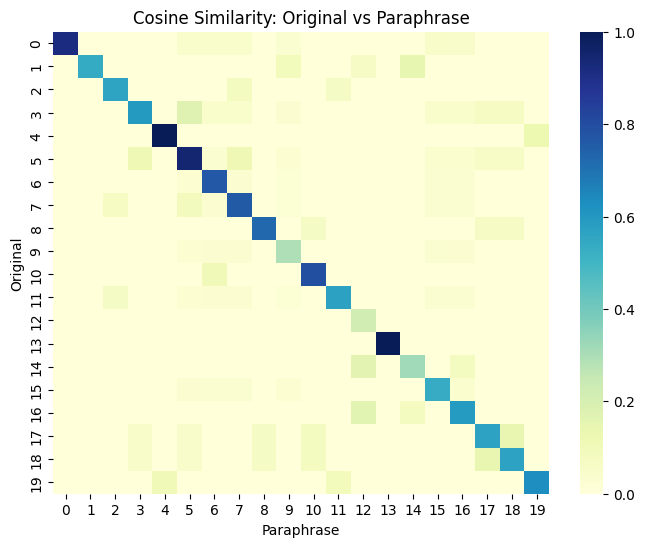

In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sample = aug_df.sample(20, random_state=42)

pairs = []
for idx, row in sample.iterrows():
    pairs.append([row['original'], row['paraphrase']])

orig_texts = [p[0] for p in pairs]
aug_texts  = [p[1] for p in pairs]

vectorizer = TfidfVectorizer()
mat = vectorizer.fit_transform(orig_texts + aug_texts)

sim = cosine_similarity(mat[:len(pairs)], mat[len(pairs):])

plt.figure(figsize=(8,6))
sns.heatmap(sim, annot=False, cmap='YlGnBu')
plt.title("Cosine Similarity: Original vs Paraphrase")
plt.xlabel("Paraphrase")
plt.ylabel("Original")
plt.show()


In [ ]:
sample_case = aug_df.sample(5, random_state=10)

for idx, row in sample_case.iterrows():
    print("==============================================")
    print("Kategori     :", row['category'])
    print("Original     :", row['original'])
    print("Paraphrase   :", row['paraphrase'])
    print("SynonymSwap  :", row['synonym'])


Kategori     : news
Original     : MA Ralat Pemilihan Ketua, Tidak Jadi Kamis Lusa
Paraphrase   : MA memangkas pemilihan ketuanya, tidak jadi Kamis Lusa.
BackTrans    : MA Ralat Eleksi Ketua, No Ini Kamis setelah besok.
SynonymSwap  : MA Ralat Pemilihan Ketua, Tidak Jadi Kamis Lusa
Kategori     : health
Original     : Dampak Abu Vulkanik Lebih Berbahaya Daripada Virus Corona
Paraphrase   : Dampak abu vulkanik sedikit lebih berbahaya daripada virus Corona.
BackTrans    : Abu Berapi Lebih Berbahaya daripada Virus Corona
SynonymSwap  : Dampak Abu Vulkanik Lebih Berbahaya Daripada Virus Corona
Kategori     : oto
Original     : Serupa tapi Tak Sama, Sekilas Perbedaan Teknis Suzuki Ertiga dan XL7
Paraphrase   : Serupa tapi tak senonoh, perbedaan teknis Suzuki Ertiga dan XL7.
BackTrans    : Suzuki Ert tiga dan XL7.
SynonymSwap  : Serupa tapi Tak Sama, Sekilas Perbedaan Teknis Suzuki Ertiga dan XL7
Kategori     : sport
Original     : Foto: Brittney Palmer, si Seksi Octagon UFC
Paraphrase   : F

Jumlah per kategori pada data asli:
category
finance    14168
food        4315
health      4919
hot        16330
inet        5640
news       32360
oto         4383
sport       2436
travel      6466
Name: count, dtype: int64

Jumlah per kategori pada data balanced:
category
finance    2436
food       2436
health     2436
hot        2436
inet       2436
news       2436
oto        2436
sport      2436
travel     2436
Name: count, dtype: int64

Jumlah per kategori pada data augmented:
category
finance    9744
food       9744
health     9744
hot        9744
inet       9744
news       9744
oto        9744
sport      9744
travel     9744
Name: count, dtype: int64


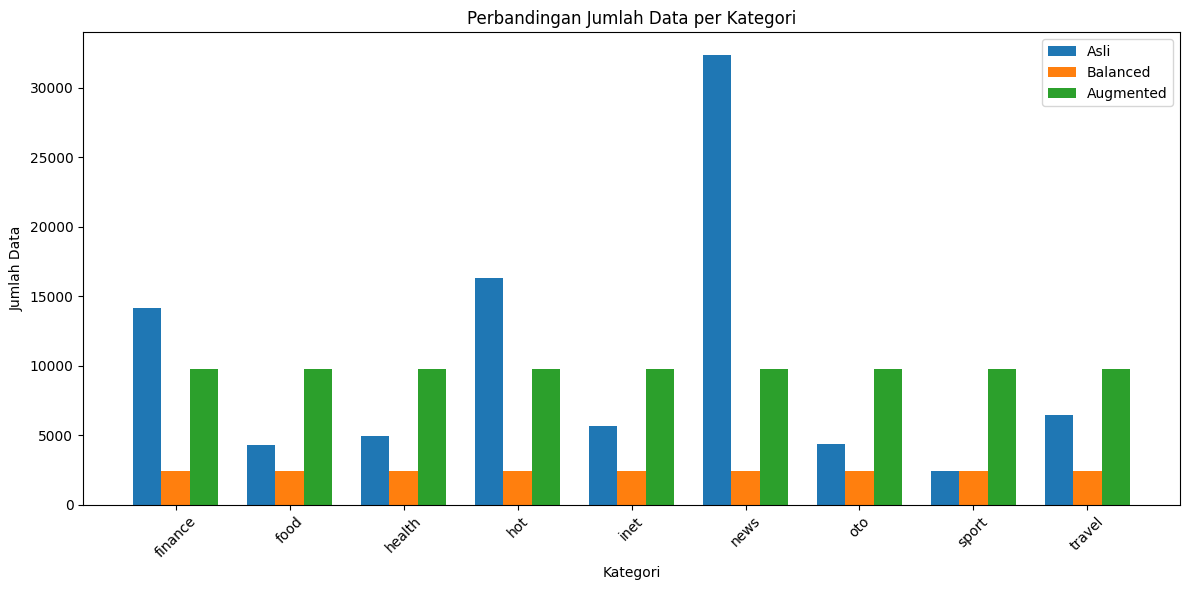

In [3]:
#Menampilkan perbandingan jumlah data dan jumlah per kategori sebelum dan setelah augmentasi
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
asli = pd.read_csv("dataset/indonesian-news-title.csv")
df = pd.read_csv("dataset/indonesian-news-title-balanced.csv")
aug_df = pd.read_csv("dataset/indonesian-news-title-augmented.csv")
df_category_counts = df['category'].value_counts().sort_index()
aug_category_counts = aug_df['category'].value_counts().sort_index()

#jumlah per kategori
print("Jumlah per kategori pada data asli:")
print(asli['category'].value_counts().sort_index())
print("\nJumlah per kategori pada data balanced:")
print(df_category_counts)
print("\nJumlah per kategori pada data augmented:")
print(aug_category_counts)

#Distribusi jumlah data per kategori asli, balanced, dan augmentasi
plt.figure(figsize=(12,6))
width = 0.25
x = np.arange(len(df_category_counts))
plt.bar(x - width, asli['category'].value_counts().sort_index(), width=width, label='Asli')
plt.bar(x, df_category_counts, width=width, label='Balanced')
plt.bar(x + width, aug_category_counts, width=width, label='Augmented')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.title('Perbandingan Jumlah Data per Kategori')
plt.xticks(x, df_category_counts.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()  